In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the data
data = pd.read_csv('../data/raw/gender.csv')


In [48]:
data.head()

,auhtor_ID,post,female
0,t2_rnjzutp,Good on you for being responsible! I know self...,1
1,t2_rnjzutp,"must go to the grocery store with their child,...",1
2,t2_rnjzutp,"things on her videos, and YouTube took the vid...",1
3,t2_rnjzutp,their app. There's also a program called SYNC ...,1
4,t2_rnjzutp,"side. If the cops don't take your side, you'll...",1


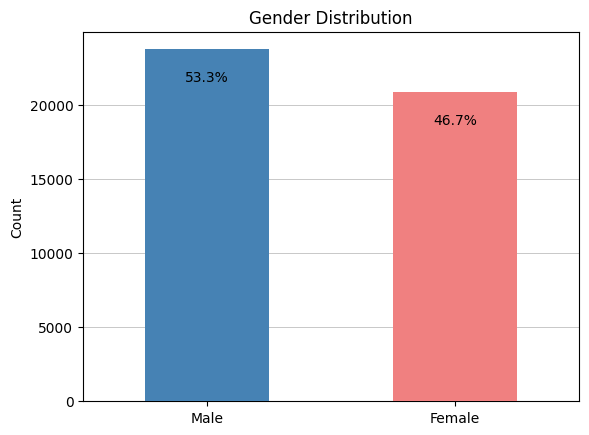

In [44]:
# Count the number of females (1) and males (0)
gender_counts = data['female'].value_counts()

# Calculate the percentage for each gender
gender_percentages = (gender_counts / gender_counts.sum()) * 100

# Create a bar plot
ax = gender_counts.plot(kind='bar', color=['steelblue', 'lightcoral'], title='Gender Distribution', zorder=3)

# Label the axes
plt.xlabel('')
plt.ylabel('Count')

# Replace the x-tick labels with 'Male' and 'Female'
ax.grid(axis='y', linestyle='-', linewidth=0.7, alpha=0.7, zorder=0)
ax.set_xticklabels(['Male', 'Female'], rotation=0)


# Add percentage labels on top of the bars
for i, v in enumerate(gender_counts):
    # Add percentage label above the bar, adjust vertical position to avoid overflow
    ax.text(i, v - 0.10 * max(gender_counts), f'{gender_percentages[i]:.1f}%', ha='center', va='bottom')

# Show the plot

plt.savefig("genderdistribution.png", dpi=300, bbox_inches='tight')

plt.show()

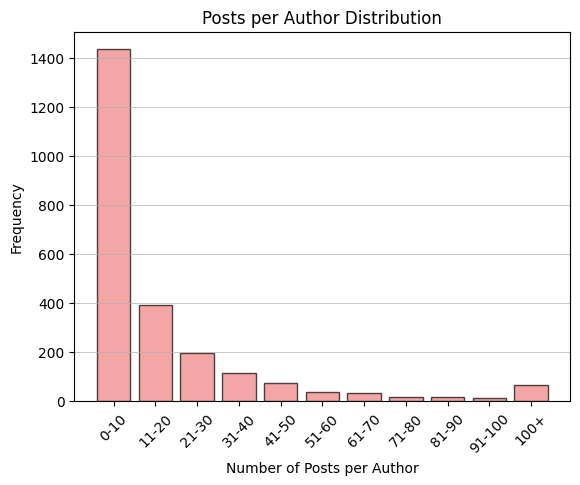

In [15]:
# Count the number of posts per author
posts_per_author = data.groupby('auhtor_ID')['post'].count()

# Define the custom bins
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 10000]  # Define bin edges
bin_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', '100+']  # Define bin labels

# Bin the posts per author
binned_posts = pd.cut(posts_per_author, bins=bins, labels=bin_labels, right=True)

# Count the frequencies for each bin
binned_counts = binned_posts.value_counts(sort=False)


# Create a bar plot for the binned data
plt.bar(binned_counts.index, binned_counts.values, color='lightcoral', edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Posts per Author Distribution')
plt.xlabel('Number of Posts per Author')
plt.ylabel('Frequency')

# Add a grid behind the bars
plt.grid(axis='y', linestyle='-', linewidth=0.7, alpha=0.7, zorder=0)

# Rotate x-tick labels for better readability
plt.xticks(rotation=45)

# Save the plot
plt.savefig("posts_per_author.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

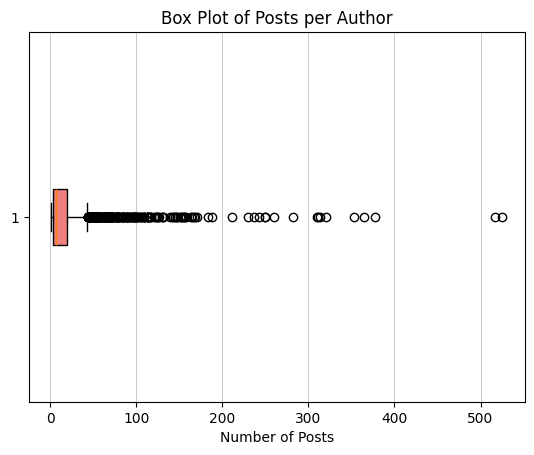

In [54]:
plt.boxplot(posts_per_author, vert=False, patch_artist=True, boxprops=dict(facecolor='lightcoral', color='black'))

# Add a title and labels
plt.title('Box Plot of Posts per Author')
plt.xlabel('Number of Posts')

# Add grid lines behind the box plot
plt.grid(axis='x', linestyle='-', linewidth=0.7, alpha=0.7, zorder=0)

# Save the plot
plt.savefig("boxplot_posts_per_author.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

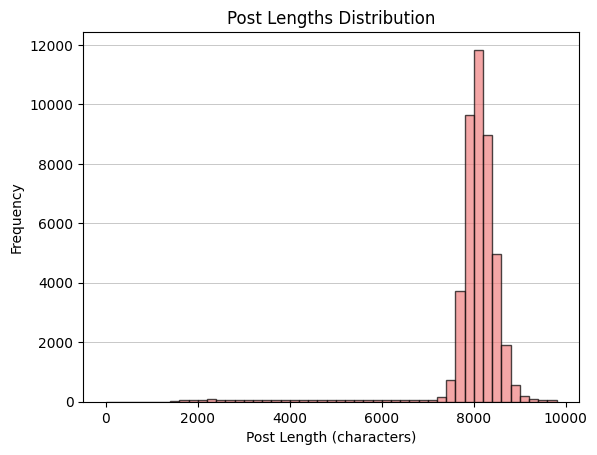

In [22]:
# Calculate the length of each post
data['post_length'] = data['post'].str.len()

# Define bins for post lengths
bins = range(0, 10000, 200)

# Create a histogram for post lengths
plt.hist(data['post_length'], bins=bins, color='lightcoral', edgecolor='black', alpha=0.7, zorder=3)

# Add titles and labels
plt.title('Post Lengths Distribution')
plt.xlabel('Post Length (characters)')
plt.ylabel('Frequency')

# Add grid lines behind the bars
plt.grid(axis='y', linestyle='-', linewidth=0.7, alpha=0.7, zorder=0)

# Save the plot
plt.savefig("post_length_distribution.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()
